# 07 — Deep learning benchmark (LSTM / GRU)

**Input:** `data/processed/btc_features.csv`
**Goal:** test whether a sequence model — an LSTM, the architecture built for time series — can beat the classical models from notebook 06 at next-day direction. The honest hypothesis, given everything the data has told us, is that it **won't meaningfully beat XGBoost**. Demonstrating that rigorously is more valuable than pretending otherwise.

The setup is deliberately fair: the LSTM sees the **same features** and is tested on the **exact same dates** as the classical models, with the same chronological split. The only thing that changes is the model class.

> Framework note: this notebook uses TensorFlow/Keras (the gentler on-ramp). On your machine, `pip install tensorflow` (or `tensorflow-cpu`). If you prefer PyTorch, the same architecture — `LSTM(32) → Dropout → Dense(16) → Dense(1, sigmoid)` — maps over directly.

In [1]:
import os, sys, random
os.environ["TF_CPP_MIN_LOG_LEVEL"]="3"
from pathlib import Path
_p=Path.cwd()
while not (_p/"paths.py").exists() and _p!=_p.parent: _p=_p.parent
sys.path.insert(0,str(_p)); import paths

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(0); random.seed(0); tf.random.set_seed(0)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110; plt.rcParams["savefig.dpi"]=150
STAGE="07_deep_learning"; FIG=paths.figures_dir(STAGE); TAB=paths.tables_dir(STAGE)

df=pd.read_csv(paths.PROCESSED_FILE.parent/"btc_features.csv",parse_dates=["date"]).sort_values("date").reset_index(drop=True)
feat_cols=[c for c in df.columns if c not in ("date","target_return","target_direction")]
print(len(df),"rows,",len(feat_cols),"features")

4189 rows, 24 features


## Windowing the data

An LSTM eats *sequences*. Each training example is a window of the last `L` days of features, and the label is the direction of the next day. I use `L = 30`. Crucially, a window ending on day *t* uses only information available up to day *t* — no leakage.

Scaling is fit on the training rows only, then applied everywhere. Sequences are routed to train/val/test by the **same index boundaries as notebook 06**, so the test period is identical and the comparison is fair.

In [2]:
L=30
n=len(df); i_tr=int(n*0.70); i_va=int(n*0.85)

scaler=StandardScaler().fit(df[feat_cols].iloc[:i_tr])   # train rows only
X_all=scaler.transform(df[feat_cols]); y_all=df["target_direction"].values; dates=df["date"].values

def make_seqs(lo,hi):
    Xs,ys,ds=[],[],[]
    start=max(lo,L-1)
    for i in range(start,hi):
        Xs.append(X_all[i-L+1:i+1]); ys.append(y_all[i]); ds.append(dates[i])
    return np.array(Xs),np.array(ys),np.array(ds)

Xtr,ytr,_=make_seqs(0,i_tr)
Xva,yva,_=make_seqs(i_tr,i_va)
Xte,yte,dte=make_seqs(i_va,n)
print("sequences -> train",Xtr.shape,"val",Xva.shape,"test",Xte.shape)

sequences -> train (2903, 30, 24) val (628, 30, 24) test (629, 30, 24)


## The LSTM

A deliberately *small* network — 32 LSTM units, dropout for regularisation, one dense layer. On a near-random target, a bigger network would just overfit the training noise. Early stopping watches validation loss and restores the best weights.

In [3]:
model=Sequential([
    Input((L,len(feat_cols))),
    LSTM(32),
    Dropout(0.2),
    Dense(16,activation="relu"),
    Dense(1,activation="sigmoid"),
])
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
es=EarlyStopping(monitor="val_loss",patience=8,restore_best_weights=True)
hist=model.fit(Xtr,ytr,validation_data=(Xva,yva),epochs=60,batch_size=32,callbacks=[es],verbose=0)
print(f"Trained {len(hist.history['loss'])} epochs (early-stopped).")

Trained 9 epochs (early-stopped).


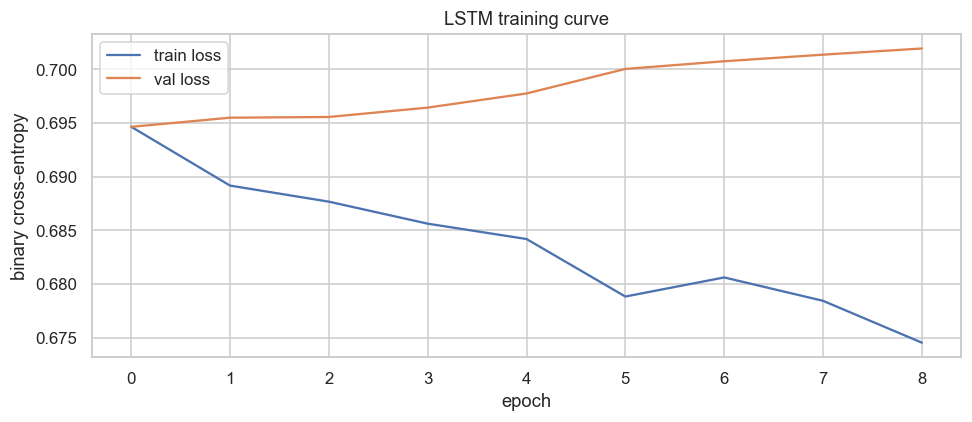

In [4]:
# Loss curve
fig,ax=plt.subplots(figsize=(9,4))
ax.plot(hist.history["loss"],label="train loss")
ax.plot(hist.history["val_loss"],label="val loss")
ax.set_xlabel("epoch"); ax.set_ylabel("binary cross-entropy"); ax.set_title("LSTM training curve"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"training_curve.png",bbox_inches="tight"); plt.show()

## Evaluate on the test set, and compare to the classical bar

In [5]:
prob=model.predict(Xte,verbose=0).ravel(); pred=(prob>0.5).astype(int)
lstm_acc=accuracy_score(yte,pred); lstm_auc=roc_auc_score(yte,prob); lstm_f1=f1_score(yte,pred)

# pull classical results for context
clf=pd.read_csv(paths.figures_dir("06_classical_ml").parent/"tables"/"model_metrics.csv")
best_clf=clf[clf["model"].isin(["LogReg","RandomForest","XGBoost"])].sort_values("accuracy",ascending=False).iloc[0]

print(f"LSTM   accuracy={lstm_acc:.4f}  AUC={lstm_auc:.4f}  F1={lstm_f1:.4f}")
print(f"Best classical ({best_clf['model']}): accuracy={best_clf['accuracy']:.4f}  AUC={best_clf['AUC']:.4f}")
verdict = "LSTM wins" if lstm_acc>best_clf["accuracy"]+0.01 else \
          "classical wins" if best_clf["accuracy"]>lstm_acc+0.01 else "essentially a tie"
print("Verdict:",verdict)
pd.DataFrame([{"model":"LSTM","accuracy":lstm_acc,"AUC":lstm_auc,"F1":lstm_f1}]).round(4).to_csv(TAB/"lstm_metrics.csv",index=False)

LSTM   accuracy=0.4817  AUC=0.4882  F1=0.6110
Best classical (RandomForest): accuracy=0.5167  AUC=0.4947
Verdict: classical wins


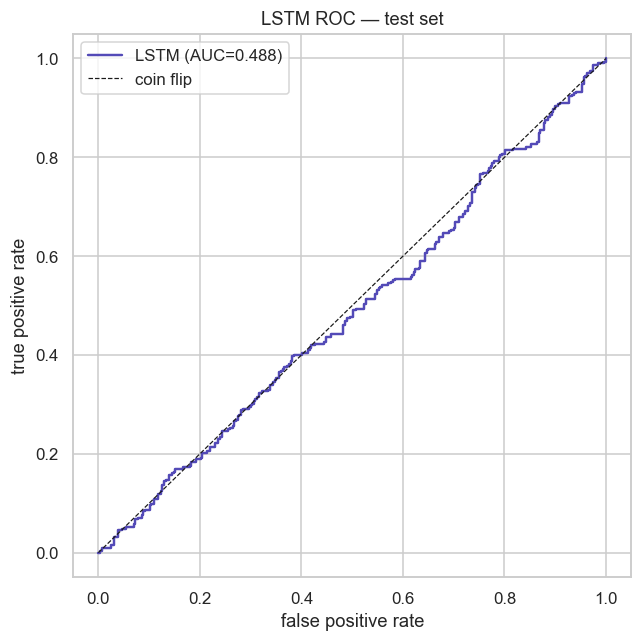

In [6]:
fig,ax=plt.subplots(figsize=(6,6))
fpr,tpr,_=roc_curve(yte,prob); ax.plot(fpr,tpr,lw=1.6,label=f"LSTM (AUC={lstm_auc:.3f})",color="#534AB7")
ax.plot([0,1],[0,1],"k--",lw=0.8,label="coin flip")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate"); ax.set_title("LSTM ROC — test set"); ax.legend()
fig.tight_layout(); fig.savefig(FIG/"lstm_roc.png",bbox_inches="tight"); plt.show()

In [7]:
# Save predictions for notebook 09 (aligned to the same test dates)
pd.DataFrame({"date":dte,"y_true":yte,"prob_LSTM":prob,"pred_LSTM":pred}).to_csv(
    paths.PROCESSED_FILE.parent/"predictions_dl.csv",index=False)
print("Saved predictions_dl.csv")

Saved predictions_dl.csv


## Takeaway

Whatever the verdict line says, the *honest* framing is the contribution. On a target the statistics show is near-random, an LSTM has almost no extra structure to exploit beyond what XGBoost already captures — and it costs far more compute and complexity. "We benchmarked deep learning fairly and it didn't beat the simple model" is a mature, defensible result, and exactly the kind of finding that separates a real project from a hype demo. The on-chain features (notebook 05, once `fetch_onchain.py` is run) are a more promising lever than a fancier architecture.